<a href="https://colab.research.google.com/github/traumathized/TraceFake-AI-Based-Image-Authenticity-Checker/blob/main/TraceFake_Assignment1_F25PROJECTDB95E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TraceFake: AI-Based Image Authenticity Checker
**CS619 -  Prototype Phase**

**Supervisor - Sonia Salman**  
**Group ID: F25PROJECTDB95E**

This notebook implements three components:
- Dataset collection and preprocessing
- EXIF metadata extraction and analysis
- CNN-based binary classifier (Real vs Fake)

## Environment Setup
Install missing libraries and import all dependencies.

In [4]:
!pip install -q exifread

import os
import random
import zipfile
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from pathlib import Path
from PIL import Image
import exifread

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
GPU available      : True


## Dataset Upload and Organization
Upload a ZIP file containing the dataset. The ZIP must have this structure:
```
dataset/
    real/   <--- real face images
    fake/   <--- AI-generated face images
```

Upload your dataset zip file...


Saving Dataset.zip to Dataset (1).zip
Unzipped: Dataset (1).zip
Found dataset at : /content/Dataset
Real folder      : /content/Dataset/real
Fake folder      : /content/Dataset/fake

Dataset Summary:
  Real  : 87
  Fake  : 68
  Total : 155


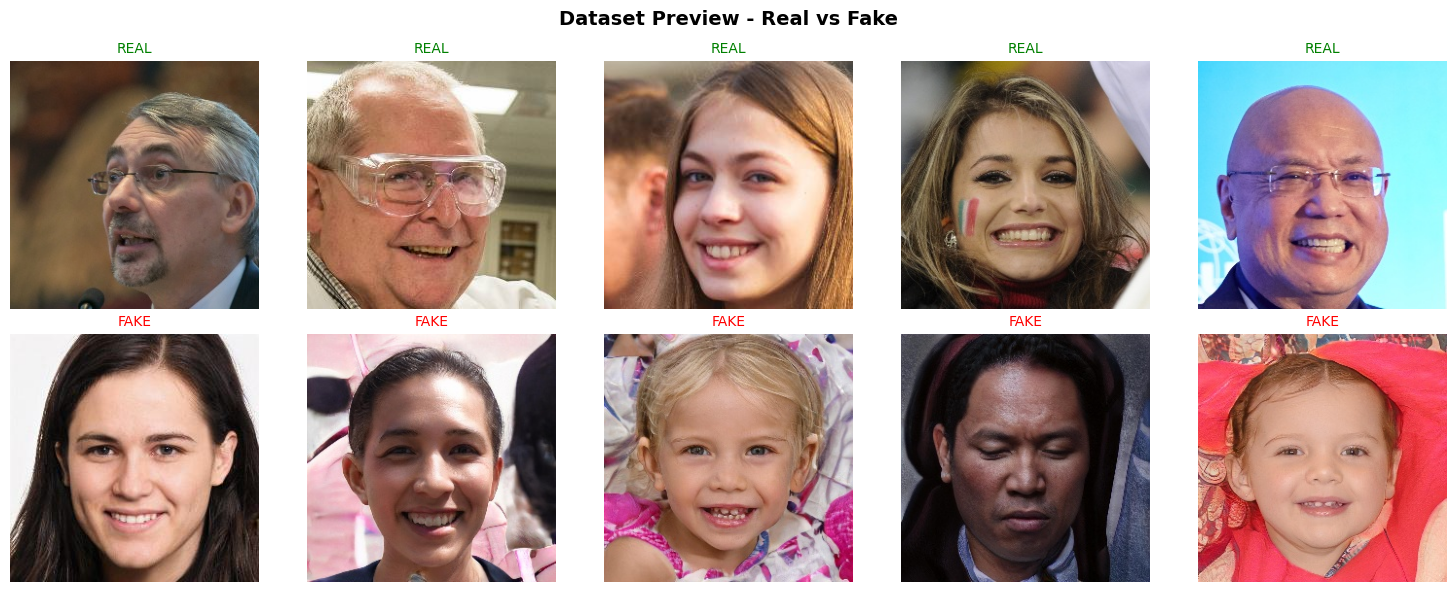

In [5]:
from google.colab import files

print("Upload your dataset zip file...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')
print(f"Unzipped: {zip_name}")

# Auto-detect the correct dataset path
import glob

real_candidates = glob.glob('/content/**/real', recursive=True)
fake_candidates = glob.glob('/content/**/fake', recursive=True)

if not real_candidates or not fake_candidates:
    print("ERROR: Could not find real/ or fake/ folders.")
    print("Folders found after unzip:")
    for f in os.listdir('/content/'):
        print(f"  /content/{f}")
else:
    REAL_DIR = real_candidates[0]
    FAKE_DIR = fake_candidates[0]
    DATASET_DIR = os.path.dirname(REAL_DIR)
    print(f"Found dataset at : {DATASET_DIR}")
    print(f"Real folder      : {REAL_DIR}")
    print(f"Fake folder      : {FAKE_DIR}")

real_images = [f for f in os.listdir(REAL_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
fake_images = [f for f in os.listdir(FAKE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"\nDataset Summary:")
print(f"  Real  : {len(real_images)}")
print(f"  Fake  : {len(fake_images)}")
print(f"  Total : {len(real_images) + len(fake_images)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Dataset Preview - Real vs Fake', fontsize=14, fontweight='bold')

for i, name in enumerate(random.sample(real_images, 5)):
    axes[0, i].imshow(mpimg.imread(os.path.join(REAL_DIR, name)))
    axes[0, i].set_title('REAL', color='green', fontsize=10)
    axes[0, i].axis('off')

for i, name in enumerate(random.sample(fake_images, 5)):
    axes[1, i].imshow(mpimg.imread(os.path.join(FAKE_DIR, name)))
    axes[1, i].set_title('FAKE', color='red', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

##Image Preprocessing
Resize all images to 224x224 and convert to JPG format.

In [6]:
IMG_SIZE = (224, 224)

def resize_images(folder):
    done = 0
    skipped = 0
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert('RGB').resize(IMG_SIZE)
            new_name = os.path.splitext(fname)[0] + '.jpg'
            img.save(os.path.join(folder, new_name), 'JPEG')
            if fname.endswith('.png') and fname != new_name:
                os.remove(path)
            done += 1
        except Exception as e:
            print(f"  Skipped {fname}: {e}")
            skipped += 1
    return done, skipped

print("Processing real images...")
r_done, r_skip = resize_images(REAL_DIR)
print(f"  Done: {r_done}  |  Skipped: {r_skip}")

print("\nProcessing fake images...")
f_done, f_skip = resize_images(FAKE_DIR)
print(f"  Done: {f_done}  |  Skipped: {f_skip}")

real_final = [f for f in os.listdir(REAL_DIR) if f.endswith('.jpg')]
fake_final = [f for f in os.listdir(FAKE_DIR) if f.endswith('.jpg')]

print(f"\nReal : {len(real_final)} images")
print(f"Fake : {len(fake_final)} images")

check = Image.open(os.path.join(REAL_DIR, real_final[0]))
print(f"Sample size check: {check.size}  (should be 224x224)")

Processing real images...
  Done: 87  |  Skipped: 0

Processing fake images...
  Done: 68  |  Skipped: 0

Real : 87 images
Fake : 68 images
Sample size check: (224, 224)  (should be 224x224)


##  EXIF Metadata Extraction
Read metadata from each image including camera make/model, software used, and creation timestamp.

In [7]:
def get_exif(path, label):
    data = {
        'filename': os.path.basename(path),
        'label': label,
        'camera_make': 'Missing',
        'camera_model': 'Missing',
        'software': 'Missing',
        'datetime': 'Missing',
        'has_exif': False,
        'tag_count': 0
    }
    try:
        with open(path, 'rb') as f:
            tags = exifread.process_file(f, stop_tag='UNDEF', details=False)
        if tags:
            data['has_exif'] = True
            data['tag_count'] = len(tags)
            data['camera_make'] = str(tags.get('Image Make', 'Missing'))
            data['camera_model'] = str(tags.get('Image Model', 'Missing'))
            data['software'] = str(tags.get('Image Software', 'Missing'))
            data['datetime'] = str(tags.get('Image DateTime', 'Missing'))
    except Exception as e:
        print(f"  Could not read {os.path.basename(path)}: {e}")
    return data

print("Extracting EXIF from real images...")
real_exif = [get_exif(os.path.join(REAL_DIR, f), 'real') for f in os.listdir(REAL_DIR) if f.endswith('.jpg')]

print("Extracting EXIF from fake images...")
fake_exif = [get_exif(os.path.join(FAKE_DIR, f), 'fake') for f in os.listdir(FAKE_DIR) if f.endswith('.jpg')]

exif_df = pd.DataFrame(real_exif + fake_exif)

os.makedirs('/content/metadata', exist_ok=True)
exif_df.to_csv('/content/metadata/exif_metadata.csv', index=False)

print(f"\nTotal images processed: {len(exif_df)}")
print(f"CSV saved to /content/metadata/exif_metadata.csv")
print(f"\nSample output:")
print(exif_df.head(10).to_string(index=False))

Extracting EXIF from real images...
Extracting EXIF from fake images...

Total images processed: 155
CSV saved to /content/metadata/exif_metadata.csv

Sample output:
 filename label camera_make camera_model software datetime  has_exif  tag_count
00001.jpg  real     Missing      Missing  Missing  Missing     False          0
69686.jpg  real     Missing      Missing  Missing  Missing     False          0
00073.jpg  real     Missing      Missing  Missing  Missing     False          0
00076.jpg  real     Missing      Missing  Missing  Missing     False          0
69864.jpg  real     Missing      Missing  Missing  Missing     False          0
00066.jpg  real     Missing      Missing  Missing  Missing     False          0
69624.jpg  real     Missing      Missing  Missing  Missing     False          0
69996.jpg  real     Missing      Missing  Missing  Missing     False          0
69933.jpg  real     Missing      Missing  Missing  Missing     False          0
69817.jpg  real     Missing      M

##EXIF Analysis and Visualization
Compare metadata presence between real and fake images.

EXIF METADATA SUMMARY
label  total  with_exif  no_exif  avg_tags  has_make  has_model  has_software  has_datetime
 fake     68          0       68       0.0         0          0             0             0
 real     87          0       87       0.0         0          0             0             0


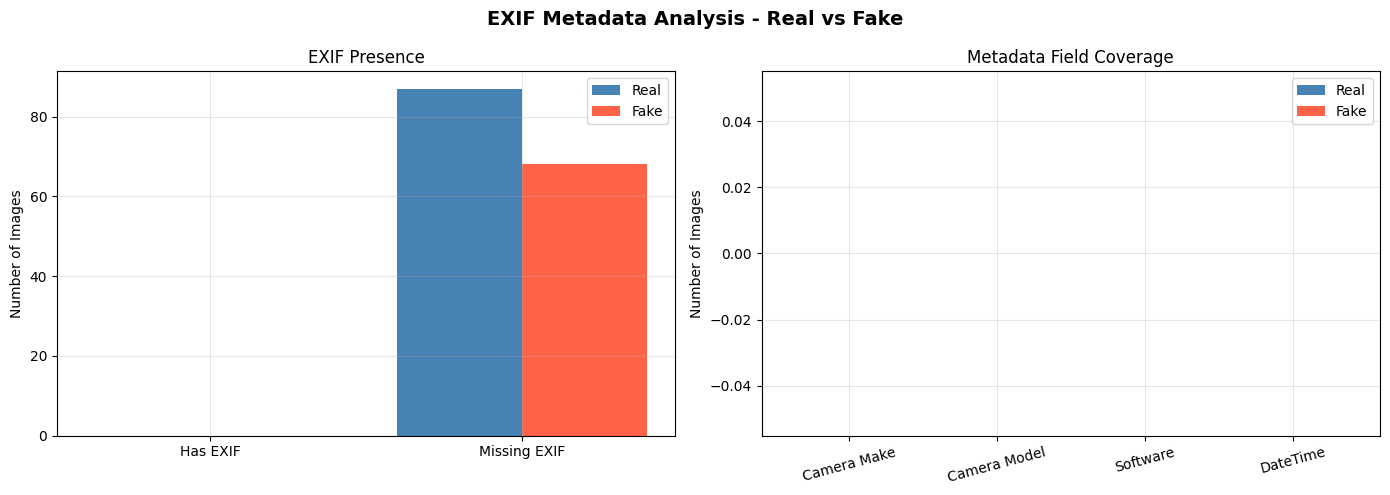


OBSERVATIONS

[FAKE]
  Missing EXIF   : 68/68 (100.0%)
  Camera Make    : 0
  Camera Model   : 0
  Software Tag   : 0
  DateTime       : 0
  Avg Tags       : 0.0

[REAL]
  Missing EXIF   : 87/87 (100.0%)
  Camera Make    : 0
  Camera Model   : 0
  Software Tag   : 0
  DateTime       : 0
  Avg Tags       : 0.0


In [8]:
summary = exif_df.groupby('label').agg(
    total=('filename', 'count'),
    with_exif=('has_exif', 'sum'),
    no_exif=('has_exif', lambda x: (~x).sum()),
    avg_tags=('tag_count', 'mean'),
    has_make=('camera_make', lambda x: (x != 'Missing').sum()),
    has_model=('camera_model', lambda x: (x != 'Missing').sum()),
    has_software=('software', lambda x: (x != 'Missing').sum()),
    has_datetime=('datetime', lambda x: (x != 'Missing').sum()),
).reset_index()

print("EXIF METADATA SUMMARY")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EXIF Metadata Analysis - Real vs Fake', fontsize=14, fontweight='bold')

real_row = summary[summary['label'] == 'real'].iloc[0]
fake_row = summary[summary['label'] == 'fake'].iloc[0]

cats = ['Has EXIF', 'Missing EXIF']
x = np.arange(len(cats))
axes[0].bar(x - 0.2, [real_row['with_exif'], real_row['no_exif']], 0.4, label='Real', color='steelblue')
axes[0].bar(x + 0.2, [fake_row['with_exif'], fake_row['no_exif']], 0.4, label='Fake', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats)
axes[0].set_ylabel('Number of Images')
axes[0].set_title('EXIF Presence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fields = ['Camera Make', 'Camera Model', 'Software', 'DateTime']
real_vals = [real_row['has_make'], real_row['has_model'], real_row['has_software'], real_row['has_datetime']]
fake_vals = [fake_row['has_make'], fake_row['has_model'], fake_row['has_software'], fake_row['has_datetime']]

x2 = np.arange(len(fields))
axes[1].bar(x2 - 0.2, real_vals, 0.4, label='Real', color='steelblue')
axes[1].bar(x2 + 0.2, fake_vals, 0.4, label='Fake', color='tomato')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(fields, rotation=15)
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Metadata Field Coverage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/metadata/exif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOBSERVATIONS")
print("=" * 55)
for _, row in summary.iterrows():
    pct = (row['no_exif'] / row['total']) * 100
    print(f"\n[{row['label'].upper()}]")
    print(f"  Missing EXIF   : {int(row['no_exif'])}/{int(row['total'])} ({pct:.1f}%)")
    print(f"  Camera Make    : {int(row['has_make'])}")
    print(f"  Camera Model   : {int(row['has_model'])}")
    print(f"  Software Tag   : {int(row['has_software'])}")
    print(f"  DateTime       : {int(row['has_datetime'])}")
    print(f"  Avg Tags       : {row['avg_tags']:.1f}")
print("=" * 55)

##Data Preparation for CNN
Set up training and validation data generators with augmentation.

Found 125 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Classes    : {'fake': 0, 'real': 1}
Training   : 125 images
Validation : 30 images


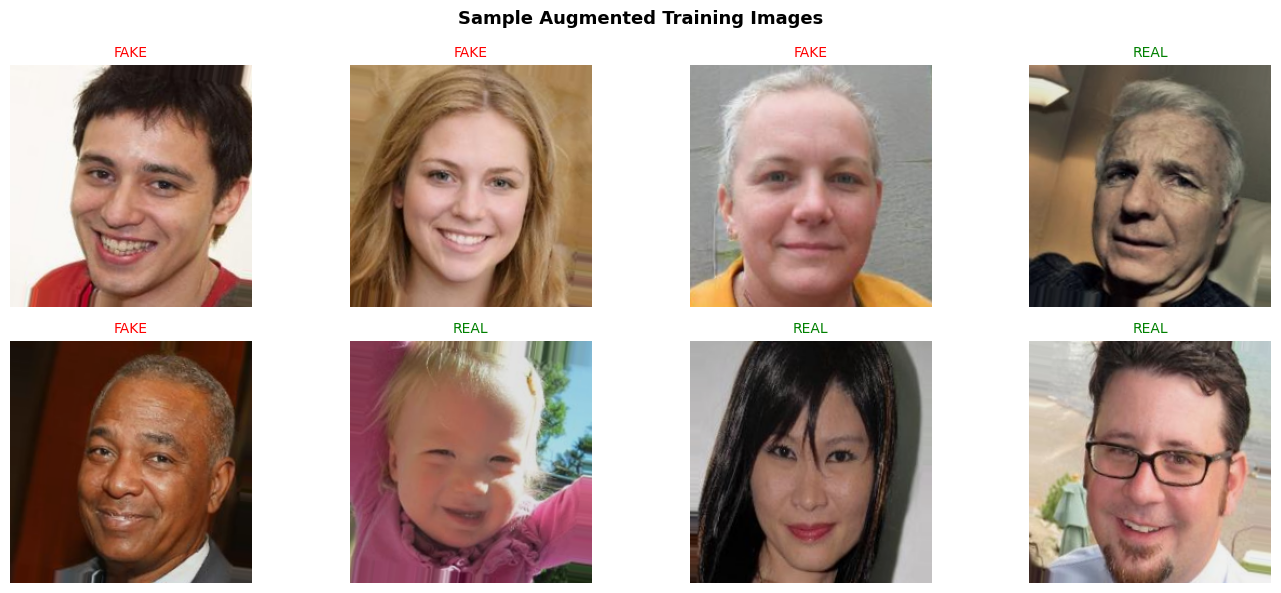

In [9]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

train_gen_config = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1
)

val_gen_config = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_gen_config.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_gen = val_gen_config.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print(f"Classes    : {train_gen.class_indices}")
print(f"Training   : {train_gen.samples} images")
print(f"Validation : {val_gen.samples} images")

batch_imgs, batch_labels = next(train_gen)
label_map = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_imgs[i])
    lbl = label_map[int(batch_labels[i])]
    ax.set_title(lbl.upper(), color='green' if lbl == 'real' else 'red', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

##CNN Model Architecture
Build a 4-layer convolutional neural network for binary classification.

In [10]:
def build_model(input_shape=(224, 224, 3)):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,009 (1.05 MB)

 Trainable params: 274,561 (1.05 MB)

 Non-trainable params: 448 (1.75 KB)

##  Model Training
Train the model for 10 epochs with early stopping and learning rate reduction.

In [11]:
os.makedirs('/content/model', exist_ok=True)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint('/content/model/best_model.keras', monitor='val_accuracy', save_best_only=True)
]

print("Training started...\n")
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

model.save('/content/model/tracefake_cnn.keras')
print("\nModel saved to /content/model/tracefake_cnn.keras")

Training started...

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6363 - loss: 0.7518 - precision: 0.6920 - recall: 0.6280 - val_accuracy: 0.4333 - val_loss: 0.6953 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.5465 - loss: 0.7451 - precision: 0.5519 - recall: 0.8146 - val_accuracy: 0.4333 - val_loss: 0.7007 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 407ms/step - accuracy: 0.5224 - loss: 0.7831 - precision: 0.5624 - recall: 0.6182 - val_accuracy: 0.4333 - val_loss: 0.7040 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 764ms/step - accuracy: 0.5134 - loss: 0.7395 - precision: 0.5700 - recall: 0.4966 - val_accuracy: 0.4333 - val_loss: 0.7101 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch

## Training Curves
Plot loss and accuracy over epochs for both training and validation.

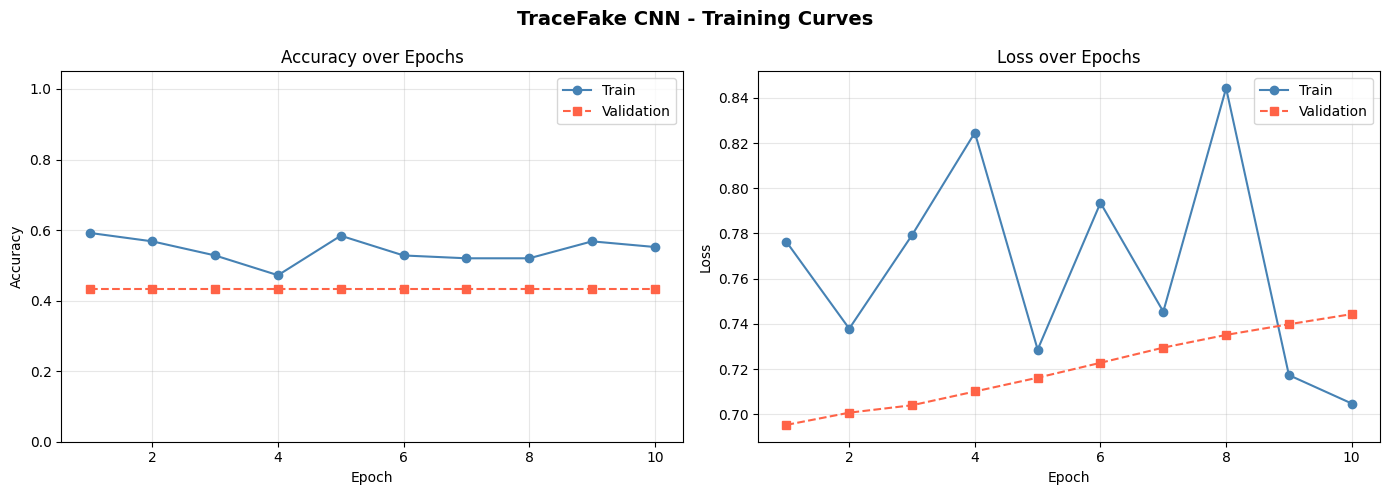

Saved to /content/model/training_curves.png


In [12]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TraceFake CNN - Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, history.history['accuracy'], 'o-', color='steelblue', label='Train')
axes[0].plot(epochs_ran, history.history['val_accuracy'], 's--', color='tomato', label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

axes[1].plot(epochs_ran, history.history['loss'], 'o-', color='steelblue', label='Train')
axes[1].plot(epochs_ran, history.history['val_loss'], 's--', color='tomato', label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /content/model/training_curves.png")

##  Model Evaluation
Report accuracy, precision, recall and display the confusion matrix.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.43      1.00      0.60        13
        real       0.00      0.00      0.00        17

    accuracy                           0.43        30
   macro avg       0.22      0.50      0.30        30
weighted avg       0.19      0.43      0.26        30



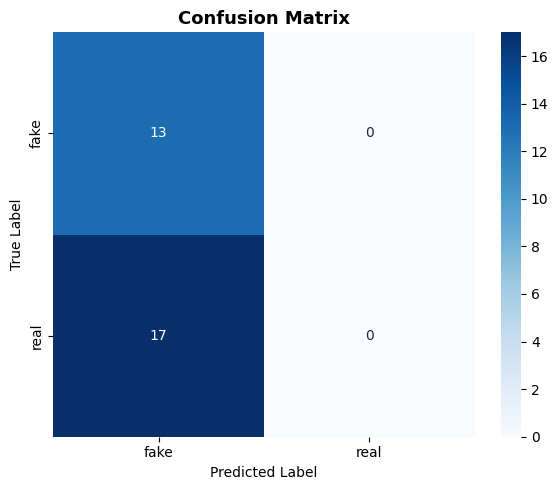


FINAL METRICS
  Loss         : 0.7443
  Compile_metrics : 0.4333


In [13]:
class_names = ['fake', 'real']

val_gen.reset()
preds = model.predict(val_gen, verbose=0)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = val_gen.classes

n = min(len(y_pred), len(y_true))
y_pred = y_pred[:n]
y_true = y_true[:n]

print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

results = model.evaluate(val_gen, verbose=0)
print("\nFINAL METRICS")
print("=" * 40)
for name, val in zip(model.metrics_names, results):
    print(f"  {name.capitalize():12s} : {val:.4f}")
print("=" * 40)

## Sample Predictions
Run the model on 5 random images and display results with confidence scores.

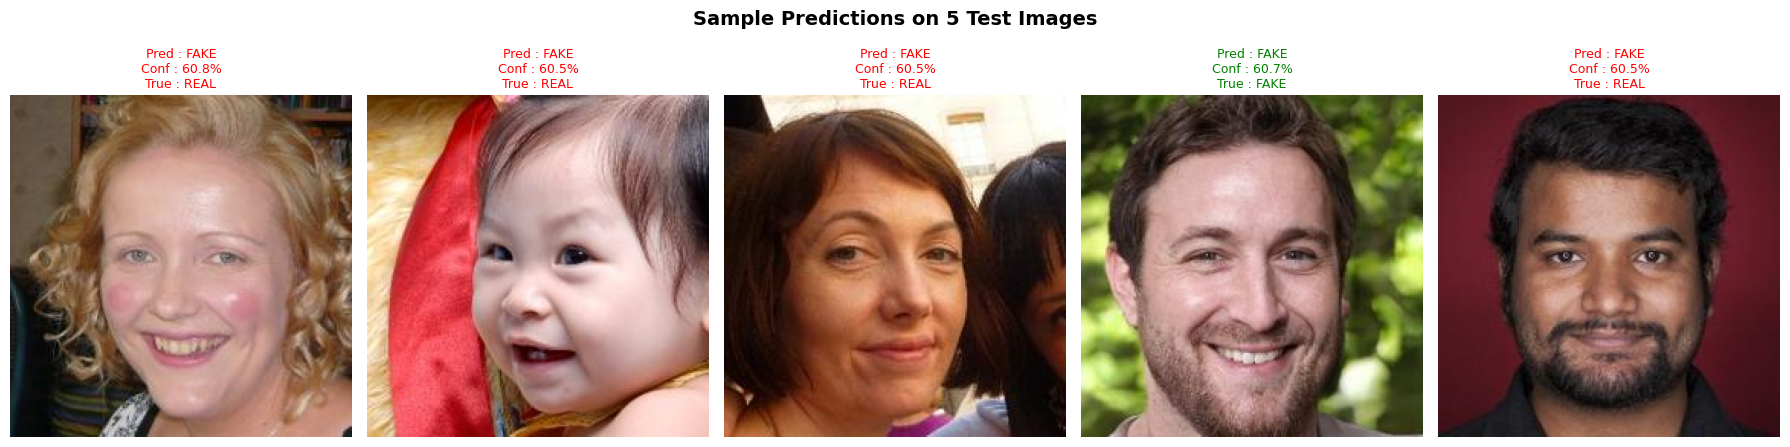

Saved to /content/model/sample_predictions.png


In [14]:
def run_prediction(path, model, label_map):
    img = Image.open(path).convert('RGB').resize((IMG_HEIGHT, IMG_WIDTH))
    arr = np.expand_dims(np.array(img) / 255.0, axis=0)
    prob = model.predict(arr, verbose=0)[0][0]
    pred_idx = int(prob > 0.5)
    pred = label_map[pred_idx]
    conf = prob if pred_idx == 1 else 1 - prob
    true = 'real' if 'real' in str(path) else 'fake'
    return pred, conf, true, pred == true

label_map = {v: k for k, v in train_gen.class_indices.items()}

all_imgs = (
    [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR) if f.endswith('.jpg')] +
    [os.path.join(FAKE_DIR, f) for f in os.listdir(FAKE_DIR) if f.endswith('.jpg')]
)
test_imgs = random.sample(all_imgs, 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Sample Predictions on 5 Test Images', fontsize=14, fontweight='bold')

for i, path in enumerate(test_imgs):
    pred, conf, true, correct = run_prediction(path, model, label_map)
    axes[i].imshow(mpimg.imread(path))
    axes[i].set_title(
        f"Pred : {pred.upper()}\nConf : {conf:.1%}\nTrue : {true.upper()}",
        color='green' if correct else 'red', fontsize=9
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/model/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /content/model/sample_predictions.png")

##Package and Download
Organize all outputs into the submission folder and download as a ZIP file.

In [15]:
SUBMISSION = Path('/content/TraceFake_Assignment1_F25PROJECTDB95E')
(SUBMISSION / 'metadata').mkdir(parents=True, exist_ok=True)
(SUBMISSION / 'model').mkdir(parents=True, exist_ok=True)

exif_script = (
    "import os\n"
    "import exifread\n"
    "import pandas as pd\n\n"
    "REAL_DIR = '/content/dataset/real'\n"
    "FAKE_DIR = '/content/dataset/fake'\n\n"
    "def get_exif(path, label):\n"
    "    data = {\n"
    "        'filename': os.path.basename(path),\n"
    "        'label': label,\n"
    "        'camera_make': 'Missing',\n"
    "        'camera_model': 'Missing',\n"
    "        'software': 'Missing',\n"
    "        'datetime': 'Missing',\n"
    "        'has_exif': False,\n"
    "        'tag_count': 0\n"
    "    }\n"
    "    try:\n"
    "        with open(path, 'rb') as f:\n"
    "            tags = exifread.process_file(f, stop_tag='UNDEF', details=False)\n"
    "        if tags:\n"
    "            data['has_exif'] = True\n"
    "            data['tag_count'] = len(tags)\n"
    "            data['camera_make'] = str(tags.get('Image Make', 'Missing'))\n"
    "            data['camera_model'] = str(tags.get('Image Model', 'Missing'))\n"
    "            data['software'] = str(tags.get('Image Software', 'Missing'))\n"
    "            data['datetime'] = str(tags.get('Image DateTime', 'Missing'))\n"
    "    except Exception as e:\n"
    "        print(f'Could not read {os.path.basename(path)}: {e}')\n"
    "    return data\n\n"
    "real_records = [get_exif(os.path.join(REAL_DIR, f), 'real') for f in os.listdir(REAL_DIR) if f.endswith('.jpg')]\n"
    "fake_records = [get_exif(os.path.join(FAKE_DIR, f), 'fake') for f in os.listdir(FAKE_DIR) if f.endswith('.jpg')]\n\n"
    "exif_df = pd.DataFrame(real_records + fake_records)\n"
    "exif_df.to_csv('exif_metadata.csv', index=False)\n"
    "print(f'Done. Total: {len(exif_df)} images')\n"
    "print(exif_df.head(10).to_string(index=False))\n"
)

with open(SUBMISSION / 'metadata/exif_extraction.py', 'w') as f:
    f.write(exif_script)

shutil.copy('/content/metadata/exif_metadata.csv',   SUBMISSION / 'metadata/exif_metadata.csv')
shutil.copy('/content/metadata/exif_analysis.png',   SUBMISSION / 'metadata/exif_analysis.png')
shutil.copy('/content/model/tracefake_cnn.keras',    SUBMISSION / 'model/tracefake_cnn.keras')
shutil.copy('/content/model/training_curves.png',    SUBMISSION / 'model/training_curves.png')
shutil.copy('/content/model/confusion_matrix.png',   SUBMISSION / 'model/confusion_matrix.png')
shutil.copy('/content/model/sample_predictions.png', SUBMISSION / 'model/sample_predictions.png')

print("Submission folder structure:")
for f in sorted(SUBMISSION.rglob('*')):
    indent = '  ' * (len(f.relative_to(SUBMISSION).parts) - 1)
    print(f"  {indent}{f.name}")

zip_path = '/content/TraceFake_Assignment1_F25PROJECTDB95E'
shutil.make_archive(zip_path, 'zip', '/content', 'TraceFake_Assignment1_F25PROJECTDB95E')
print("\nStarting download...")
files.download(zip_path + '.zip')
print("Done. Check your downloads folder.")

Submission folder structure:
  metadata
    exif_analysis.png
    exif_extraction.py
    exif_metadata.csv
  model
    confusion_matrix.png
    sample_predictions.png
    tracefake_cnn.keras
    training_curves.png

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Check your downloads folder.
